In [ ]:
import pandas as pd
import numpy as np


In [ ]:
df=pd.read_csv(r"/content/fake_or_real_news.csv")
df

,Unnamed: 0,title,text,label
0,8476,You Can Smell Hillary’s Fear,"Daniel Greenfield, a Shillman Journalism Fello...",FAKE
1,10294,Watch The Exact Moment Paul Ryan Committed Pol...,Google Pinterest Digg Linkedin Reddit Stumbleu...,FAKE
2,3608,Kerry to go to Paris in gesture of sympathy,U.S. Secretary of State John F. Kerry said Mon...,REAL
3,10142,Bernie supporters on Twitter erupt in anger ag...,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",FAKE
4,875,The Battle of New York: Why This Primary Matters,It's primary day in New York and front-runners...,REAL
...,...,...,...,...
6330,4490,State Department says it can't find emails fro...,The State Department told the Republican Natio...,REAL
6331,8062,The ‘P’ in PBS Should Stand for ‘Plutocratic’ ...,The ‘P’ in PBS Should Stand for ‘Plutocratic’ ...,FAKE
6332,8622,Anti-Trump Protesters Are Tools of the Oligarc...,Anti-Trump Protesters Are Tools of the Oligar...,FAKE
6333,4021,"In Ethiopia, Obama seeks progress on peace, se...","ADDIS ABABA, Ethiopia —President Obama convene...",REAL


In [ ]:
df.columns

Index(['Unnamed: 0', 'title', 'text', 'label'], dtype='object')

In [ ]:
df = df.drop('Unnamed: 0', axis=1)
df

,title,text,label
0,You Can Smell Hillary’s Fear,"Daniel Greenfield, a Shillman Journalism Fello...",FAKE
1,Watch The Exact Moment Paul Ryan Committed Pol...,Google Pinterest Digg Linkedin Reddit Stumbleu...,FAKE
2,Kerry to go to Paris in gesture of sympathy,U.S. Secretary of State John F. Kerry said Mon...,REAL
3,Bernie supporters on Twitter erupt in anger ag...,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",FAKE
4,The Battle of New York: Why This Primary Matters,It's primary day in New York and front-runners...,REAL
...,...,...,...
6330,State Department says it can't find emails fro...,The State Department told the Republican Natio...,REAL
6331,The ‘P’ in PBS Should Stand for ‘Plutocratic’ ...,The ‘P’ in PBS Should Stand for ‘Plutocratic’ ...,FAKE
6332,Anti-Trump Protesters Are Tools of the Oligarc...,Anti-Trump Protesters Are Tools of the Oligar...,FAKE
6333,"In Ethiopia, Obama seeks progress on peace, se...","ADDIS ABABA, Ethiopia —President Obama convene...",REAL


In [ ]:
df.shape

(6335, 3)

In [ ]:
df.describe

<bound method NDFrame.describe of                                                   title  \
0                          You Can Smell Hillary’s Fear   
1     Watch The Exact Moment Paul Ryan Committed Pol...   
2           Kerry to go to Paris in gesture of sympathy   
3     Bernie supporters on Twitter erupt in anger ag...   
4      The Battle of New York: Why This Primary Matters   
...                                                 ...   
6330  State Department says it can't find emails fro...   
6331  The ‘P’ in PBS Should Stand for ‘Plutocratic’ ...   
6332  Anti-Trump Protesters Are Tools of the Oligarc...   
6333  In Ethiopia, Obama seeks progress on peace, se...   
6334  Jeb Bush Is Suddenly Attacking Trump. Here's W...   

                                                   text label  
0     Daniel Greenfield, a Shillman Journalism Fello...  FAKE  
1     Google Pinterest Digg Linkedin Reddit Stumbleu...  FAKE  
2     U.S. Secretary of State John F. Kerry said Mon...  REAL  
3     — Kaydee King (@KaydeeKing) November 9, 2016 T...  FAKE  
4     It's primary day in New York and front-runners...  REAL  
...                                                 ...   ...  
6330  The State Department told the Republican Natio...  REAL  
6331  The ‘P’ in PBS Should Stand for ‘Plutocratic’ ...  FAKE  
6332   Anti-Trump Protesters Are Tools of the Oligar...  FAKE  
6333  ADDIS ABABA, Ethiopia —President Obama convene...  REAL  
6334  Jeb Bush Is Suddenly Attacking Trump. Here's W...  REAL  

[6335 rows x 3 columns]>

In [ ]:
# 1. Check null values
print("Null Values:")
print(df.isnull().sum())

# 2. Remove duplicate rows
print("\nDuplicate Rows:", df.duplicated().sum())
df = df.drop_duplicates()

# 3. Frequency count of Fake and Real news
print("\nFake vs Real Frequency:")
print(df['label'].value_counts())


Null Values:
title    0
text     0
label    0
dtype: int64

Duplicate Rows: 29

Fake vs Real Frequency:
label
REAL    3154
FAKE    3152
Name: count, dtype: int64


In [ ]:
df.shape

(6306, 3)

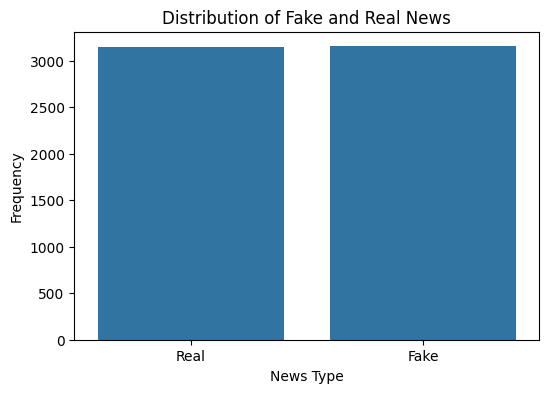

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))

sns.countplot(x='label', data=df)

plt.title('Distribution of Fake and Real News')
plt.xlabel('News Type')
plt.ylabel('Frequency')

plt.xticks([0, 1], ['Real', 'Fake'])
plt.show()


In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt


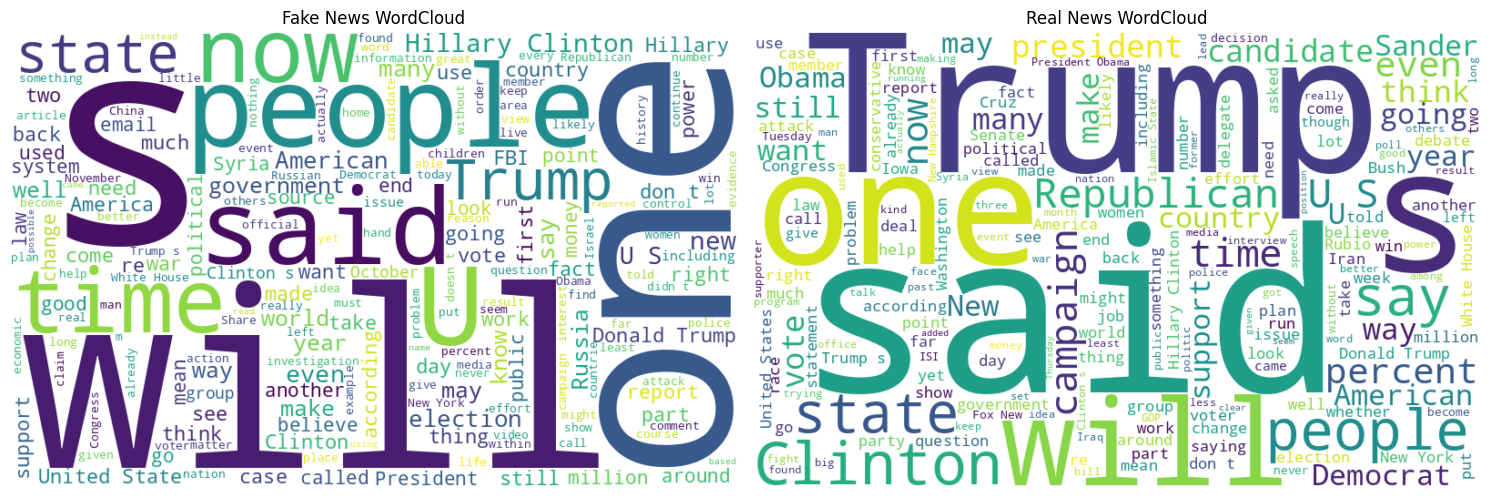

In [ ]:
fake_text = ' '.join(df[df['label'] == 'FAKE']['text'].astype(str))
real_text = ' '.join(df[df['label'] == 'REAL']['text'].astype(str))

plt.figure(figsize=(15, 7))

# Fake News WordCloud
plt.subplot(1, 2, 1)

fake_wordcloud = WordCloud(
    width=800,
    height=500,
    background_color='white'
).generate(fake_text)

plt.imshow(fake_wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Fake News WordCloud')


# Real News WordCloud
plt.subplot(1, 2, 2)

real_wordcloud = WordCloud(
    width=800,
    height=500,
    background_color='white'
).generate(real_text)

plt.imshow(real_wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Real News WordCloud')

plt.tight_layout()
plt.show()

In [ ]:
import nltk

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [ ]:
import re
import string
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# Common chat words
chat_words = {
    'u': 'you',
    'ur': 'your',
    'r': 'are',
    'btw': 'between',
    'idk': 'i do not know',
    'lol': 'laugh',
    'omg': 'oh my god',
    'thx': 'thanks',
    'pls': 'please',
    'plz': 'please'
}

def preprocess_text(text):
    # Convert to string and lowercase
    text = str(text).lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    # Handle chat words
    words = text.split()
    words = [chat_words.get(word, word) for word in words]
    text = ' '.join(words)

    # Remove emojis, punctuation, numbers and special characters
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Tokenization
    words = text.split()

    # Remove stopwords
    words = [word for word in words if word not in stop_words]

    # Lemmatization
    words = [lemmatizer.lemmatize(word) for word in words]

    return ' '.join(words)

# Apply preprocessing
df['clean_text'] = df['text'].apply(preprocess_text)

# Display original and cleaned text
df[['text', 'clean_text']].head()


/tmp/ipykernel_684/1059563898.py:53: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['clean_text'] = df['text'].apply(preprocess_text)


,text,clean_text
0,"Daniel Greenfield, a Shillman Journalism Fello...",daniel greenfield shillman journalism fellow f...
1,Google Pinterest Digg Linkedin Reddit Stumbleu...,google pinterest digg linkedin reddit stumbleu...
2,U.S. Secretary of State John F. Kerry said Mon...,u secretary state john f kerry said monday sto...
3,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",kaydee king kaydeeking november lesson tonight...
4,It's primary day in New York and front-runners...,primary day new york front runner hillary clin...


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Map 'FAKE' to 0 and 'REAL' to 1 for models that require numerical labels
y_train_numeric = y_train.map({'FAKE': 0, 'REAL': 1})
y_test_numeric = y_test.map({'FAKE': 0, 'REAL': 1})

# ============================================================
# 1. LOGISTIC REGRESSION
# ============================================================

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

print("Logistic Regression trained successfully!")


# ============================================================
# 2. NAIVE BAYES
# ============================================================

nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

nb_pred = nb_model.predict(X_test)

print("Naive Bayes trained successfully!")


# ============================================================
# 3. DECISION TREE
# ============================================================

dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

print("Decision Tree trained successfully!")


# ============================================================
# 4. RANDOM FOREST
# ============================================================

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest trained successfully!")


# ============================================================
# 5. XGBOOST
# ============================================================

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train_numeric)

xgb_pred = xgb_model.predict(X_test)

print("XGBoost trained successfully!")


# ============================================================
# ALL MODELS TRAINED
# ============================================================

print("\nAll 5 models have been trained successfully!")

Logistic Regression trained successfully!
Naive Bayes trained successfully!
Decision Tree trained successfully!
Random Forest trained successfully!
XGBoost trained successfully!

All 5 models have been trained successfully!


Model Performance Comparison:


,Model,Accuracy,Precision,Recall
0,Logistic Regression,0.910460,0.933110,0.884311
1,XGBoost,0.911252,0.923328,0.896989
2,Random Forest,0.900158,0.913257,0.884311
3,Naive Bayes,0.883518,0.855882,0.922345
4,Decision Tree,0.793978,0.809683,0.768621


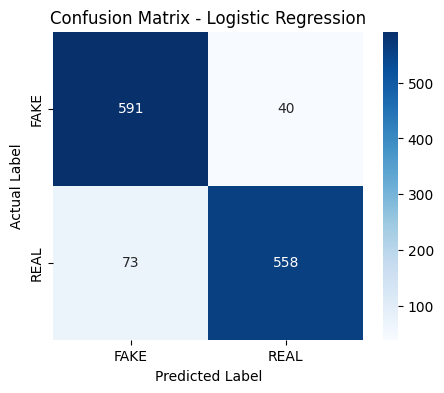

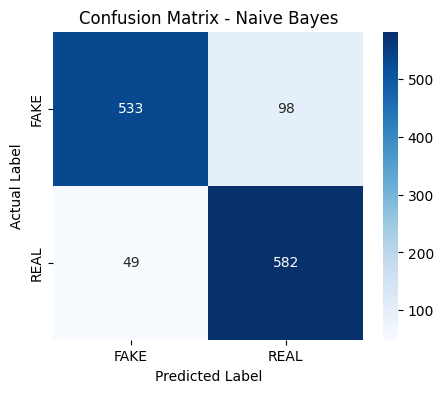

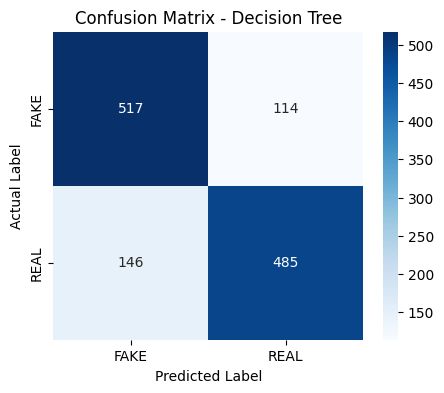

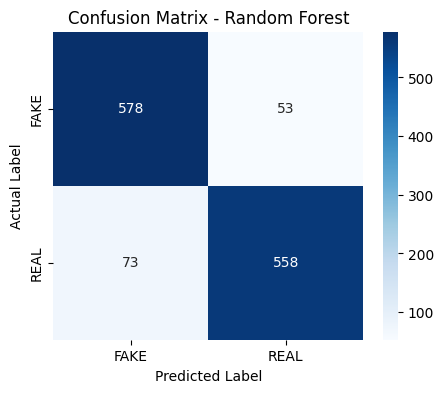

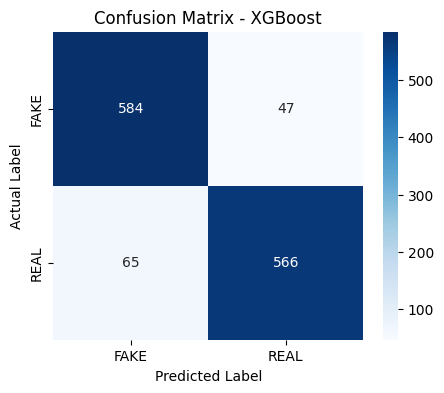


Best Model Based on Precision:
Model: Logistic Regression
Precision: 0.9331
Accuracy: 0.9105
Recall: 0.8843


In [ ]:
# ============================================================
# MODEL EVALUATION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix
)
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# Convert XGBoost numerical predictions to string labels to match y_test
xgb_pred_str = pd.Series(xgb_pred).map({0: 'FAKE', 1: 'REAL'}).values

# Store all models and predictions
models = {
    "Logistic Regression": lr_pred,
    "Naive Bayes": nb_pred,
    "Decision Tree": dt_pred,
    "Random Forest": rf_pred,
    "XGBoost": xgb_pred_str
}


# ============================================================
# CALCULATE METRICS
# ============================================================

results = []

for model_name, predictions in models.items():

    accuracy = accuracy_score(y_test, predictions)

    precision = precision_score(
        y_test,
        predictions,
        pos_label='REAL' # Changed from 1 to 'REAL'
    )

    recall = recall_score(
        y_test,
        predictions,
        pos_label='REAL' # Changed from 1 to 'REAL'
    )

    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall
    })


# ============================================================
# COMPARISON DATAFRAME
# ============================================================

results_df = pd.DataFrame(results)

# Sort according to Precision
results_df = results_df.sort_values(
    by="Precision",
    ascending=False
).reset_index(drop=True)


# Display results
print("Model Performance Comparison:")
display(results_df)


# ============================================================
# CONFUSION MATRICES
# ============================================================

for model_name, predictions in models.items():

    cm = confusion_matrix(y_test, predictions)

    plt.figure(figsize=(5, 4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["FAKE", "REAL"],
        yticklabels=["FAKE", "REAL"]
    )

    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("Actual Label")

    plt.show()


# ============================================================
# BEST MODEL BASED ON PRECISION
# ============================================================

best_model = results_df.iloc[0]

print("\nBest Model Based on Precision:")
print("Model:", best_model["Model"])
print("Precision:", round(best_model["Precision"], 4))
print("Accuracy:", round(best_model["Accuracy"], 4))
print("Recall:", round(best_model["Recall"], 4))

Model Comparison:


,Model,Accuracy,Precision,Recall
0,Logistic Regression,0.910460,0.933110,0.884311
1,XGBoost,0.911252,0.923328,0.896989
2,Random Forest,0.900158,0.913257,0.884311
3,Naive Bayes,0.883518,0.855882,0.922345
4,Decision Tree,0.793978,0.809683,0.768621


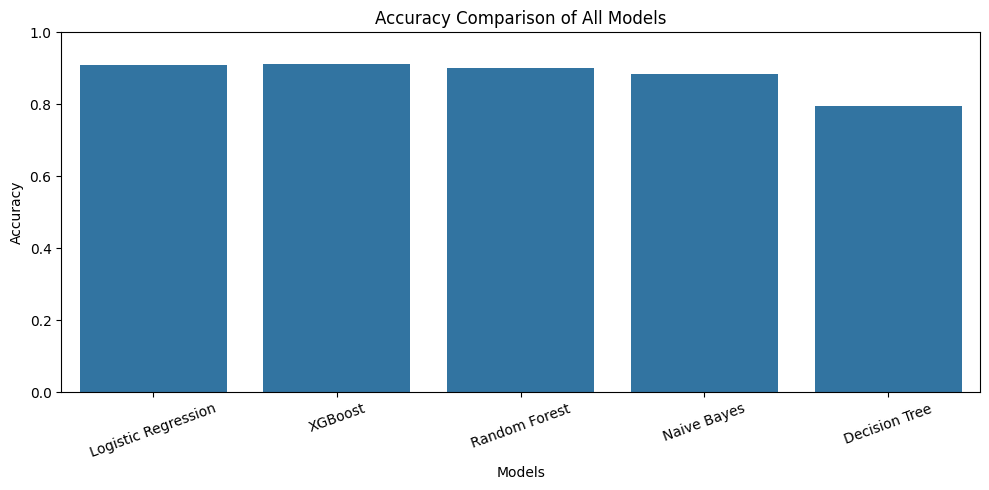

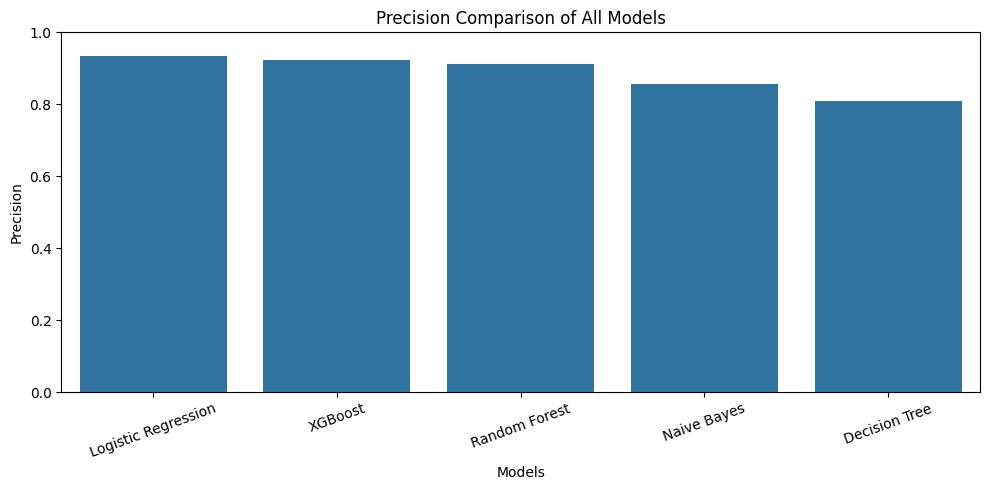

BEST MODEL BASED ON PRECISION
Model     : Logistic Regression
Precision : 0.9331
Accuracy  : 0.9105
Recall    : 0.8843


In [ ]:
# ============================================================
# MODEL COMPARISON TABLE
# ============================================================

# Sort models by Precision (highest first)
results_df = results_df.sort_values(
    by="Precision",
    ascending=False
).reset_index(drop=True)

print("Model Comparison:")
display(results_df)


# ============================================================
# ACCURACY COMPARISON
# ============================================================

plt.figure(figsize=(10, 5))

sns.barplot(
    data=results_df,
    x="Model",
    y="Accuracy"
)

plt.title("Accuracy Comparison of All Models")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.xticks(rotation=20)
plt.ylim(0, 1)

plt.tight_layout()
plt.show()


# ============================================================
# PRECISION COMPARISON
# ============================================================

plt.figure(figsize=(10, 5))

sns.barplot(
    data=results_df,
    x="Model",
    y="Precision"
)

plt.title("Precision Comparison of All Models")
plt.xlabel("Models")
plt.ylabel("Precision")
plt.xticks(rotation=20)
plt.ylim(0, 1)

plt.tight_layout()
plt.show()


# ============================================================
# BEST MODEL
# ============================================================

best_model = results_df.iloc[0]

print("====================================")
print("BEST MODEL BASED ON PRECISION")
print("====================================")
print("Model     :", best_model["Model"])
print("Precision :", round(best_model["Precision"], 4))
print("Accuracy  :", round(best_model["Accuracy"], 4))
print("Recall    :", round(best_model["Recall"], 4))
